In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import os

import warnings
warnings.filterwarnings('ignore')

In [2]:
from airquality import datamodules as datamodules

svi_map = {
    'NO$_2$ (ppb)': 8,
    'SO$_2$ (ppb)': 7,
    'CO (ppm)': 6,
    'PM$_{2.5}$ ($\mu$g/m$^3$)': 5,
    'PM$_{10}$ ($\mu$g/m$^3$)': 4,
    'Temperature ($^{\circ}$C)': 3,
    'Relative Humidity (%)': 2,
    'Precipitation (mm)': 1,
    'SVI (%)': 0,
}

coi_map = {
    'NO$_2$ (ppb)': 8,
    'SO$_2$ (ppb)': 7,
    'CO (ppm)': 6,
    'PM$_{2.5}$ ($\mu$g/m$^3$)': 5,
    'PM$_{10}$ ($\mu$g/m$^3$)': 4,
    'Temperature ($^{\circ}$C)': 3,
    'Relative Humidity (%)': 2,
    'Precipitation (mm)': 1,
    'COI (%)': 0,
}


svi = datamodules.make('airquality_svi_daily')
svi.setup('none')

coi = datamodules.make('airquality_coi_daily')
coi.setup('none')

In [3]:
from airquality.analysis.plotting import labels_map
from scipy.stats import t

def split_parameters(x, base_params):
    for param in base_params:
        if x.startswith(param):
            if len(x) == len(param):
                return param, '1'
            if x.endswith('^2'):
                return param, param
            if x[len(param):] in base_params:
                return param, x[len(param):]
    return None, None

def prepare_grid(df, ticks_map, values='mean'):
    agg_df = df.dropna(subset=['param1', 'param2']).pivot(
        columns='param2',
        index='param1',
        values=values,
    )
    agg_df = agg_df.sort_index(key=lambda x : x.map(ticks_map), axis=0)
    agg_df = agg_df.sort_index(key=lambda x : x.map(ticks_map), axis=1)

    for ii in range(len(agg_df)):
        for jj in range(len(agg_df)):
            if ii < jj and not np.isnan(agg_df.iloc[ii,jj]):
                agg_df.iloc[jj,ii] = agg_df.iloc[ii,jj]
                agg_df.iloc[ii,jj] = np.nan
            if ii == jj:
                agg_df.iloc[ii,jj] = np.nan

    return agg_df

In [ ]:
def plot_reri(ax, 
              folder, 
              features, 
              mean_column='risk_ratio', 
              ci_columns=['lower_ci', 'upper_ci'], 
              labels_map=labels_map, 
              ticks_map=svi_map, 
              cbar=True,
              title=None,
              **kwargs):
    """ Plot the actual RERI (RR_{AB} - RR_{A} - RR_{B} + 1)
    """
    trial_dirs = glob(os.path.join(os.environ['MODELS_DIR'], folder, 'trial_*'))
    folder_df = []        
    for jj, trial_dir in enumerate(trial_dirs):
        fold_dirs = glob(f'{trial_dir}/fold_*')
        for kk, fold_dir in enumerate(fold_dirs):
            df_base = pd.read_csv(f'{fold_dir}/model_summary.csv', index_col='parameter', usecols=['parameter', 'coef', 'stderr'])
            df_base.loc['1', 'coef'] = 0.0
            df_base.loc['1', 'stderr'] = 0.0
            df_base = df_base.dropna()

            # Compute baseline RR and variance from coefs
            df_base['risk_ratio'] = np.exp(df_base['coef'])
            df_base['lower_ci'] = np.exp(df_base['coef'] - 1.96 * df_base['stderr'])
            df_base['upper_ci'] = np.exp(df_base['coef'] + 1.96 * df_base['stderr'])
            df_base['variance'] = ((df_base['upper_ci'] - df_base['lower_ci']) / 2 / 1.96)**2
            
            df = pd.read_csv(f'{fold_dir}/model_summary.csv', usecols=['parameter', 'coef', 'stderr'])
            params_split = df['parameter'].apply(lambda x : split_parameters(x, features))
            params_split = pd.DataFrame(params_split.tolist(), columns=['param1', 'param2'])
            df['param1'] = params_split['param1']
            df['param2'] = params_split['param2']
            df = df.dropna().reset_index()

            df['coef'] = df['coef'] + df_base.loc[df['param1'], 'coef'].values + df_base.loc[df['param2'], 'coef'].values
            df['stderr'] = np.sqrt(df['stderr']**2 + df_base.loc[df['param1'], 'stderr'].values**2 + df_base.loc[df['param2'], 'stderr'].values**2)

            df['risk_ratio'] = np.exp(df['coef'])
            df['lower_ci'] = np.exp(df['coef'] - 1.96 * df['stderr'])
            df['upper_ci'] = np.exp(df['coef'] + 1.96 * df['stderr'])
            df['variance'] = ((df['upper_ci'] - df['lower_ci']) / 2 / 1.96)**2


            df['RERI'] = df['risk_ratio'] - \
                df_base.loc[df['param1'], 'risk_ratio'].values - \
                df_base.loc[df['param2'], 'risk_ratio'].values + 1
            
            df['variance'] = df['variance'] \
                + df_base.loc[df['param1'], 'variance'].values + df_base.loc[df['param2'], 'variance'].values
            
            folder_df.append(df.dropna().reset_index().assign(trial_index=jj, fold_index=kk))
    
    folder_df = pd.concat(folder_df, axis=0)

    # Estimate variance for each trial
    folder_df['mean'] = folder_df['RERI']
    agg_df = folder_df.groupby(['param1', 'param2']).agg({
        'mean': 'mean',
        'variance': 'mean'
    })
    agg_df['variance'] = agg_df['variance'] \
        + folder_df.groupby(['param1', 'param2'])['mean'].agg(lambda x : x.pow(2).mean()) \
        - agg_df['mean'].pow(2)
    
    t_stat = (agg_df['mean']) / np.sqrt(agg_df['variance'])
    n_dof = (jj+1) * (kk+1) - 1
    agg_df['p_value'] = 2 * t.sf(np.abs(t_stat), n_dof)

    
    agg_df = agg_df.reset_index()
    agg_df['param1'] = agg_df['param1'].map(labels_map)
    agg_df['param2'] = agg_df['param2'].map(labels_map)

    coef_df = prepare_grid(agg_df, ticks_map, values='mean')
    mask_df = prepare_grid(agg_df, ticks_map, values='p_value') < 0.05
    mask_df = prepare_grid(agg_df, ticks_map, values='mean').abs() > 0.01

    # Remove units from labels
    coef_df.index = coef_df.index.str.split('(').str[0].str[:-1]
    coef_df.columns = coef_df.columns.str.split('(').str[0].str[:-1]
    mask_df.index = coef_df.index
    mask_df.columns = coef_df.columns

    kwargs = dict(zorder=3, cmap='bwr', vmin=-0.4, vmax=0.4, linewidth=0.5)
    sns.heatmap(ax=ax, data=coef_df, annot=False, cbar=False, **kwargs)
    sns.heatmap(ax=ax, data=coef_df, annot=coef_df, fmt='.02f', annot_kws={'size': 7},
                cbar=cbar, mask=~mask_df, **kwargs)

    ax.grid(False)
    ax.tick_params(which='both', length=0)
    ax.set(xlabel=None, ylabel=None, title=title)

    # plt.savefig(os.path.join(os.environ['MODELS_DIR'], folder, 'reri.pdf'), bbox_inches='tight')

    return agg_df.dropna(subset=['param1', 'param2'])

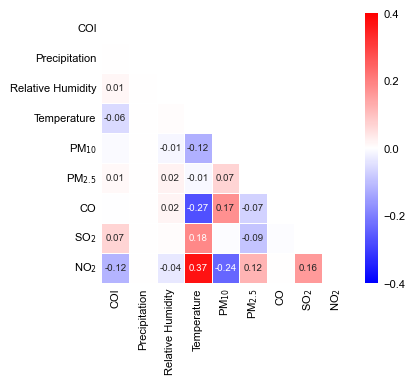

In [20]:
socio_var = 'coi'
datamodule = coi
ticks_map = coi_map

plt.rcParams['font.size'] = 8

fig, ax = plt.subplots(1, 1, figsize=(4, 3.5), sharex=True, sharey=True)
plot_reri(ax, f'{socio_var}/GLM/lag7/stlsq', datamodule.exog_features, ticks_map=ticks_map);
ax.collections[1].colorbar.ax.set_yticks([-0.4, -0.2, 0, 0.2, 0.4])
ax.collections[1].colorbar.ax.tick_params(which='both', length=0)
plt.savefig(f'{os.environ["MODELS_DIR"]}/{socio_var}/reri.pdf', bbox_inches='tight')

In [ ]:
def plot_multiplicative_interaction(ax, 
                                    folder, 
                                    features, 
                                    mean_column='risk_ratio', 
                                    ci_columns=['lower_ci', 'upper_ci'], 
                                    labels_map=labels_map, 
                                    ticks_map=svi_map, 
                                    title=None,
                                    **kwargs):
    """ Plot the coefficient for the multiplicative interaction terms
    """
    trial_dirs = glob(os.path.join(os.environ['MODELS_DIR'], folder, 'trial_*'))
    folder_df = []        
    for jj, trial_dir in enumerate(trial_dirs):
        fold_dirs = glob(f'{trial_dir}/fold_*')
        for kk, fold_dir in enumerate(fold_dirs):
            df = pd.read_csv(f'{fold_dir}/model_summary.csv', usecols=['parameter', mean_column, *ci_columns])
            params_split = df['parameter'].apply(lambda x : split_parameters(x, features))
            params_split = pd.DataFrame(params_split.tolist(), columns=['param1', 'param2'])
            df['param1'] = params_split['param1']
            df['param2'] = params_split['param2']            

            folder_df.append(df.dropna().reset_index().assign(trial_index=jj, fold_index=kk))
    
    folder_df = pd.concat(folder_df, axis=0)

    # Estimate variance for each trial
    folder_df['mean'] = folder_df[mean_column]
    folder_df['variance'] = 0.
    for CI_col in ci_columns:
        folder_df['variance'] += np.power(np.abs(folder_df['mean'] - folder_df[CI_col]) / 1.96, 2) / len(ci_columns)

    agg_df = folder_df.groupby(['param1', 'param2']).agg({
        'mean': 'mean',
        'variance': 'mean'
    })
    agg_df['variance'] = agg_df['variance'] \
        + folder_df.groupby(['param1', 'param2'])['mean'].agg(lambda x : x.pow(2).mean()) \
        - agg_df['mean'].pow(2)
    
    t_stat = (agg_df['mean'] - 1) / np.sqrt(agg_df['variance'])
    n_dof = (jj+1) * (kk+1) - 1
    agg_df['p_value'] = 2 * t.sf(np.abs(t_stat), n_dof)

    
    agg_df = agg_df.reset_index()
    agg_df['param1'] = agg_df['param1'].map(labels_map)
    agg_df['param2'] = agg_df['param2'].map(labels_map)

    coef_df = prepare_grid(agg_df, ticks_map, values='mean')
    mask_df = prepare_grid(agg_df, ticks_map, values='p_value') < 0.05


    kwargs = dict(zorder=3, cmap='bwr', vmin=0.6, vmax=1.4, linewidth=0.5)
    sns.heatmap(ax=ax, data=coef_df, annot=False, cbar=False, **kwargs)
    sns.heatmap(ax=ax, data=coef_df, annot=coef_df, fmt='.02f', mask=~mask_df, **kwargs)

    ax.grid(False)
    ax.tick_params(which='both', length=0)
    ax.set(xlabel=None, ylabel=None, title=title)

    return agg_df.dropna(subset=['param1', 'param2'])

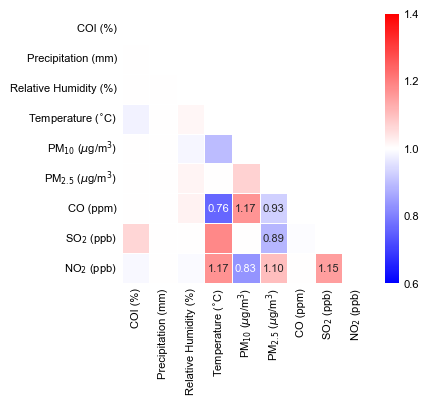

In [84]:
socio_var = 'coi'
datamodule = coi
ticks_map = coi_map

plt.rcParams['font.size'] = 8

fig, ax = plt.subplots(1, 1, figsize=(4, 3.5), sharex=True, sharey=True)
plot_multiplicative_interaction(ax, f'{socio_var}/GLM/lag7/stlsq', datamodule.exog_features, ticks_map=ticks_map);
ax.collections[1].colorbar.ax.set_yticks([0.6, 0.8, 1, 1.2, 1.4])
ax.collections[1].colorbar.ax.tick_params(which='both', length=0)